In [27]:
import pandas as pd

df = pd.read_csv('../data/interim/profile_with_clusters.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Cluster
0,23,84,-1.0,2,0,7,73,0,1,0,...,Medium,Public,Positive,3,0,High School,Near,1,67,2
1,19,64,-1.0,1,0,8,59,0,1,2,...,Medium,Public,Negative,4,0,College,Moderate,0,61,2
2,24,98,-1.0,1,1,7,91,1,1,2,...,Medium,Public,Neutral,4,0,Postgraduate,Near,1,74,1
3,29,89,-1.0,1,1,8,98,1,1,1,...,Medium,Public,Negative,4,0,High School,Moderate,1,71,1
4,19,92,-1.0,1,1,6,65,1,1,3,...,High,Public,Neutral,4,0,College,Near,0,70,1


In [28]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   float64
 3   Access_to_Resources         6607 non-null   int64  
 4   Extracurricular_Activities  6607 non-null   int64  
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   int64  
 8   Internet_Access             6607 non-null   int64  
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Family_Income               6607 non-null   object 
 11  Teacher_Quality             6607 non-null   object 
 12  School_Type                 6607 non-null   object 
 13  Peer_Influence              6607 

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
Cluster                       0
dtype: int64

Text(0.5, 1.0, 'Hours Studied vs Exam Score')

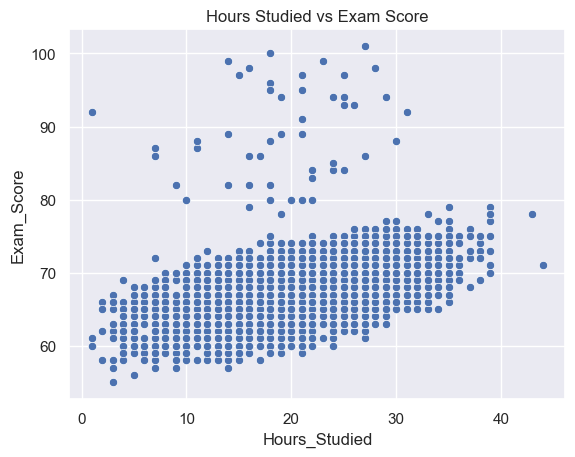

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)
plt.title('Hours Studied vs Exam Score')

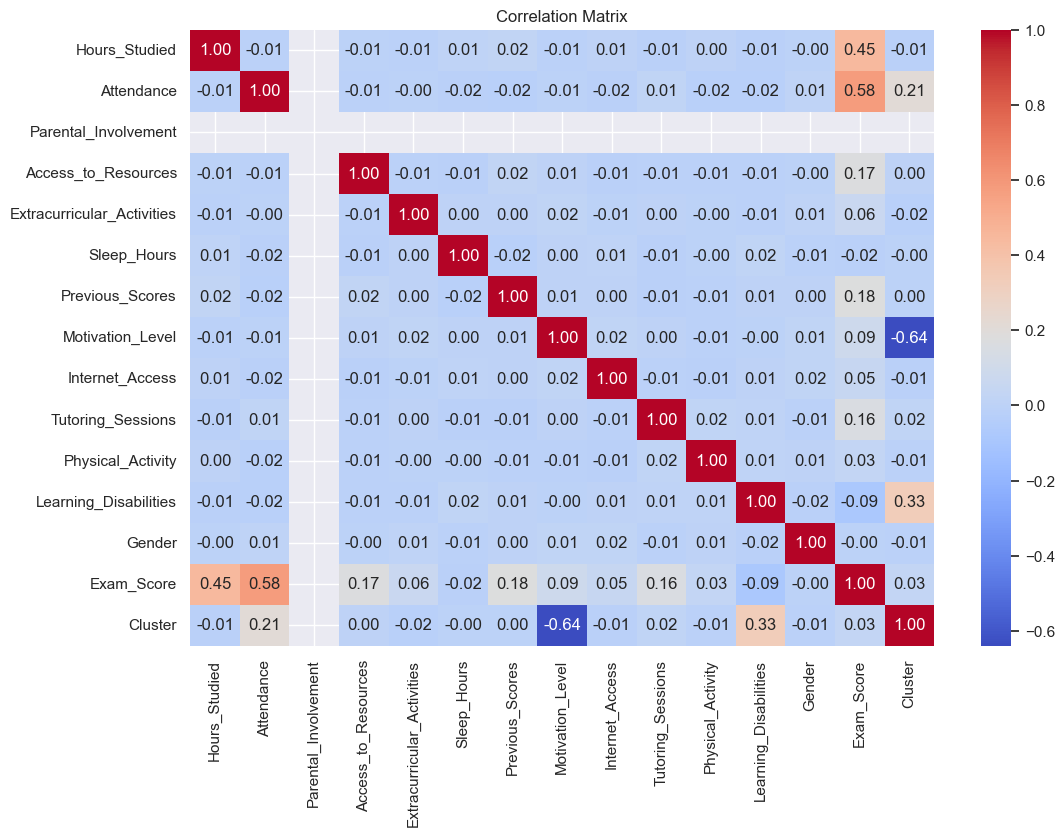

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only include numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

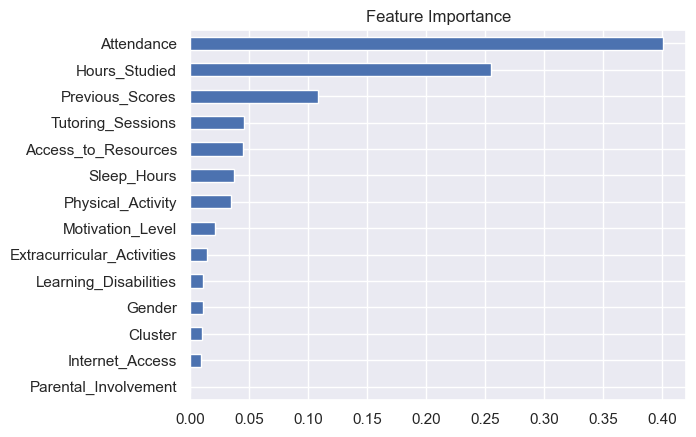

In [31]:
from sklearn.ensemble import RandomForestRegressor

X = numeric_df.drop(columns=['Exam_Score'])
y = numeric_df['Exam_Score']

model = RandomForestRegressor()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

In [32]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create a contingency table between two categorical variables
contingency_table = pd.crosstab(df['Gender'], df['Internet_Access'])

# Run the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print results
print(f"Chi-square: {chi2:.4f}, P-value: {p:.4f}")

Chi-square: 1.4004, P-value: 0.2366


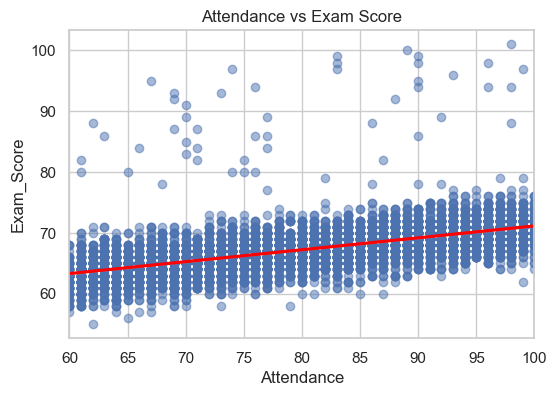

Slope (Attendance → Exam Score): 0.1958


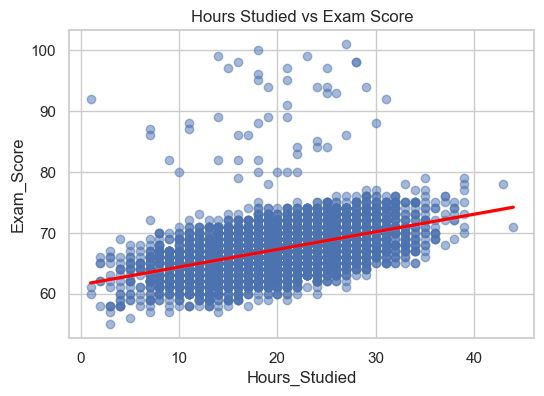

Slope (Hours Studied → Exam Score): 0.2893


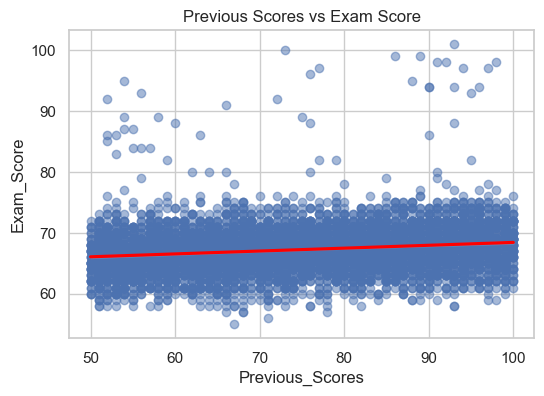

Slope (Previous Scores → Exam Score): 0.0473


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

# === Plot 1: Attendance vs Exam Score ===
plt.figure(figsize=(6, 4))
sns.regplot(x='Attendance', y='Exam_Score', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Attendance vs Exam Score')
plt.xlim(60, 100)
plt.grid(True)
plt.show()

# Print slope
slope, intercept = np.polyfit(df['Attendance'], df['Exam_Score'], 1)
print(f"Slope (Attendance → Exam Score): {slope:.4f}")

# === Plot 2: Hours Studied vs Exam Score ===
plt.figure(figsize=(6, 4))
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Hours Studied vs Exam Score')
plt.grid(True)
plt.show()

slope, intercept = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)
print(f"Slope (Hours Studied → Exam Score): {slope:.4f}")

# === Plot 3: Previous Scores vs Exam Score ===
plt.figure(figsize=(6, 4))
sns.regplot(x='Previous_Scores', y='Exam_Score', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Previous Scores vs Exam Score')
plt.grid(True)
plt.show()

slope, intercept = np.polyfit(df['Previous_Scores'], df['Exam_Score'], 1)
print(f"Slope (Previous Scores → Exam Score): {slope:.4f}")

In [34]:
low_attendance = df[df['Attendance'] < 80]['Exam_Score']
high_attendance = df[df['Attendance'] >= 80]['Exam_Score']

print(f"Low Attendance (<80%): {len(low_attendance)} students")
print(f"High Attendance (≥80%): {len(high_attendance)} students")

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(low_attendance, high_attendance, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ The difference in Exam Scores is statistically significant.")
else:
    print("❌ The difference in Exam Scores is not statistically significant.")

Low Attendance (<80%): 3254 students
High Attendance (≥80%): 3353 students
T-statistic: -46.3972
P-value: 0.0000
✅ The difference in Exam Scores is statistically significant.
